In [1]:
import sys, os
import torch
import numpy as np
sys.path.append('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/src')
from model_enc_dec_cos import *
import numpy as np
import glob
import os
import sys
from tqdm import tqdm
import math


/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/src/model_enc_dec_cos.py:538: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast()


In [2]:
simid = 663
output_dir = '/mnt/ceph/users/spandey/discodj_runs/test_3gpc/gen_cats'
os.makedirs(output_dir, exist_ok=True)
out_filename =  os.path.join(output_dir, f'generated_halo_catalog_{simid}.npy')


In [3]:
ckpt_path = f'/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/checkpoints/checkpoint_new.pt'

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint = torch.load(ckpt_path, map_location=dev)
state_dict = checkpoint["model"]
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

HaloConfig = checkpoint['config']

model = HaloDecoderModel(HaloConfig).to(dev)
model.load_state_dict(state_dict)
model.eval()

# Compile transformer blocks for optimized inference (kernel fusion, reduced overhead)
for i in range(len(model.transformer.h)):
    model.transformer.h[i] = torch.compile(model.transformer.h[i], mode="default")

ctx = torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16)
all_param = np.loadtxt('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/checkpoints/quijote_params.txt')
dmo_dir = '/mnt/ceph/users/spandey/discodj_runs/test_3gpc/full_rhog_LH//'
# simids = np.loadtxt('/work/nvme/bdne/yzhang116/quijote_halos/quijote_test_idx.txt', dtype=int)
simids = np.arange(2000)
files = [dmo_dir + f'{simid}/dmo_fields_subvols_grid_8_LH_{simid}.npy' for simid in simids]



BoxSize = 3000.0
grid = 3 * 64
nsubox = (grid)**3
num_chunks = (3*4)**3//4
chunk_size = (nsubox + num_chunks - 1) // num_chunks
print(f'Number of subboxes: {nsubox}, chunk size: {chunk_size}, number of chunks: {num_chunks}')
# rank = int(os.environ.get("SLURM_PROCID", 0))
# Ndevices = int(os.environ.get("SLURM_NTASKS", 1))
# totnum = len(simids)
# num_per_device = totnum // Ndevices
# start = rank * num_per_device
# end = start + num_per_device
# start = int(sys.argv[1])
# end = int(sys.argv[2])


nvocab = 131
start_token = nvocab + 1
space_token = nvocab + 2
pad_token = nvocab + 3
end_token = nvocab + 4
target_len = 296

pos_vocab = 40
add_space_token = False
dim_tot = 8
dim_prop = 5

xarray = np.arange(pos_vocab) * (BoxSize / pos_vocab / grid)
xarray = np.concatenate((xarray, [BoxSize/grid]))
dx = BoxSize / (pos_vocab * grid)
bins_digitize = np.zeros((dim_prop, nvocab+1))
bins_digitize[0,:-1] = np.linspace(12.7, 15.0, nvocab)
bins_digitize[0,-1] = 15.0
for i in range(1,4):
    bins_digitize[i,:-1] = np.linspace(-1250, 1250, nvocab)
    bins_digitize[i,-1] = 1250.0
bins_digitize[4,:-1] = np.linspace(1.0, 16.0, nvocab)
bins_digitize[4,-1] = 16.0
bins_step = np.zeros(dim_prop)
bins_step[0] = (15.0 - 12.7) / (nvocab - 1)
for i in range(1,4):
    bins_step[i] = (1250.0 - (-1250.0)) / (nvocab - 1)
bins_step[4] = (16.0 - 1.0) / (nvocab - 1)

def get_prop_pos(X_val):
    pos_infer_all = []
    prop_infer_all = []
    for jx in tqdm(range(grid)):
        for jy in range(grid):
            for jz in range(grid):
                sentence_here = X_val[jx, jy, jz]
                if add_space_token:
                    ntokens_per_halo = dim_tot + 1
                else:
                    ntokens_per_halo = dim_tot
                ind_start_token = np.where(sentence_here == start_token)[0][0]
                
                if end_token in sentence_here:
                    ind_end_token = np.where(sentence_here == end_token)[0][0]
                    Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)
                    if (int(Nhalos_here) - Nhalos_here) != 0:
                        print(Nhalos_here, 'Nhalos_here is not an integer')
                    else:
                        if Nhalos_here > 0:
                            for jh in range(int(Nhalos_here)):
                                try:
                                    prop_all = np.zeros(dim_prop, dtype=np.float32)        
                                    for jp in range(dim_prop):
                                        bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 4 + jp]
                                        prop_all[jp] = (bins_digitize[jp, bin_val_jp] +np.random.uniform(-0.5,0.5) * bins_step[jp]).clip(min=bins_digitize[jp,0], max=bins_digitize[jp,-1])

                                    coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 1]] + (BoxSize/grid)*jx + np.random.uniform(-0.5,0.5)*dx) % BoxSize
                                    coord_y = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 2]] + (BoxSize/grid)*jy + np.random.uniform(-0.5,0.5)*dx) % BoxSize
                                    coord_z = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 3]] + (BoxSize/grid)*jz + np.random.uniform(-0.5,0.5)*dx) % BoxSize
                                    pos_infer_all.append([coord_x, coord_y, coord_z])
                                    prop_infer_all.append(prop_all)

                                except Exception as e:
                                    print(e)
                                    pass
                else:           
                    print('End token not found')
                    pass
    return np.array(pos_infer_all), np.array(prop_infer_all)


# for simid in simids[start:end]:
param = all_param[simid]
param = np.repeat(param[None,:], nsubox, axis=0)
params_rep = torch.tensor(param, device=dev).bfloat16()
dmo = np.load(dmo_dir+f'{simid}/dmo_fields_subvols_grid_8_LH_{simid}.npy')
# dmo = torch.from_numpy(dmo).to(dev).bfloat16()
dmo = torch.from_numpy(dmo)
dmo = torch.moveaxis(dmo, -1, 1)
outputs = []
with torch.no_grad():
    with ctx:
        for i in tqdm(range(num_chunks)):
            s = i * chunk_size
            e = min((i + 1) * chunk_size, nsubox)
            print(f'Generating sim {simid}, chunk {i+1}/{num_chunks}, samples {s} to {e}', flush=True)
            if s >= e:
                break
            dmo_chunk = dmo[s:e].to(dev).bfloat16()
            params_chunk = params_rep[s:e]

            out_chunk = model.generate(
                dmo_chunk,
                params=params_chunk,
                max_new_tokens=289,
                start_token=start_token,
                end_token=end_token,
                pad_token=pad_token,
            )

            # out_chunk: [B, L]
            B, L = out_chunk.shape

            if L < target_len:
                pad_len = target_len - L
                pad = torch.full(
                    (B, pad_len),
                    pad_token,
                    dtype=out_chunk.dtype,
                    device=out_chunk.device,
                )
                out_chunk = torch.cat([out_chunk, pad], dim=1)

            outputs.append(out_chunk)

            del dmo_chunk
            del params_chunk
            del out_chunk
            # torch.cuda.empty_cache()

output = torch.cat(outputs, dim=0)  
data = output.cpu().numpy()
data = np.int16(data)
data = np.delete(data, [1,2,3,4,5,6], axis=1)
data = data.reshape((grid,grid,grid,-1))
pos, prop = get_prop_pos(data)
prop[:,0] = np.power(10.,prop[:,0])
catalog = np.concatenate([pos, prop], axis=1)
np.save(out_filename, catalog)




Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
Using flash:  True
number of parameters: 24.54M
Number of subboxes: 7077888, chunk size: 16384, number of chunks: 432


  0%|          | 0/432 [00:00<?, ?it/s]

Generating sim 663, chunk 1/432, samples 0 to 16384


  0%|          | 1/432 [00:22<2:40:53, 22.40s/it]

Generating sim 663, chunk 2/432, samples 16384 to 32768


...

Generating sim 663, chunk 44/432, samples 704512 to 720896


 10%|█         | 44/432 [13:44<1:39:56, 15.46s/it]

Generating sim 663, chunk 45/432, samples 720896 to 737280


 10%|█         | 44/432 [13:45<2:01:19, 18.76s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.48 GiB. GPU 0 has a total capacity of 79.44 GiB of which 2.93 GiB is free. Including non-PyTorch memory, this process has 76.49 GiB memory in use. Of the allocated memory 68.93 GiB is allocated by PyTorch, and 7.06 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = np.load('/mnt/ceph/users/spandey/discodj_runs/quijote_generated_halo_cats/generated_halo_catalog_663.npy')
# df.shape
pos_gen_orig = df[:,:3]
prop_gen_orig = df[:,3:]




In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = np.load('/mnt/ceph/users/spandey/discodj_runs/test_3gpc/gen_cats/generated_halo_catalog_663.npy')
# df.shape
pos_gen = df[:,:3]
prop_gen = df[:,3:]


In [3]:
print(pos_gen.shape, prop_gen.shape)
mass_all = prop_gen[:,0]
MSTAR_CUT = 12.7
indsel = np.where(mass_all > 10**MSTAR_CUT)[0]
pos_gen = pos_gen[indsel]
prop_gen = prop_gen[indsel]
print(pos_gen.shape, prop_gen.shape)


(16486569, 3) (16486569, 5)
(16484315, 3) (16484315, 5)


(0.0, 100.0)

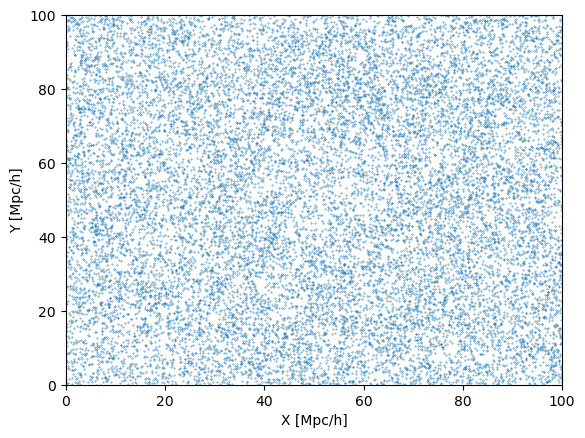

In [4]:
plt.figure()
plt.scatter(pos_gen[:,0], pos_gen[:,1], s=0.1)
plt.xlabel('X [Mpc/h]')
plt.ylabel('Y [Mpc/h]')
plt.xlim(0, 100)
plt.ylim(0, 100)


In [5]:
# pos.shape
import matplotlib.pyplot as plt
%matplotlib inline


In [6]:
import MAS_library as MASL
import Pk_library as PKL



# nax_h = 768
nax_h = 1536
BoxSize = 3000.0
# MAS = 'TSC'
MAS = 'NGP'
verbose = True

delta_mock = np.zeros((nax_h,nax_h,nax_h), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_gen.astype(np.float32), delta_mock, BoxSize, MAS, verbose=verbose)

# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
delta_mock /= np.mean(delta_mock, dtype=np.float64);  delta_mock -= 1.0


axis=0
threads=32
# compute power spectrum
Pk_mock = PKL.Pk(delta_mock, BoxSize, axis, MAS, threads, verbose)
k_mock_js       = Pk_mock.k3D
Pk0_mock_js     = Pk_mock.Pk[:,0] #monopole







Using NGP mass assignment scheme
Time taken = 4.853 seconds


Computing power spectrum of the field...
Time to complete loop = 112.55
Time taken = 124.83 seconds


In [7]:
from colossus.cosmology import cosmology
from colossus.halo import mass_so

snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/latin_hypercube_HR'
isim = 663
snap_num = 3
redshift = 0.5

cosmo_params = np.loadtxt('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/checkpoints/quijote_params.txt')[isim]

Om, Ob, h0, ns, sigma8 = cosmo_params
params = {
    'flat': True, 'H0': h0 * 100, 'Om0': Om,
    'Ob0': Ob, 'sigma8': sigma8, 'ns': ns
}
cosmology.setCosmology('myCosmo', persistence='', **params)

# Load Rockstar catalog
snapdir = f"{snap_dir_base}/{isim}"
catalog_file = f"{snapdir}/out_{snap_num}_pid.list"

with open(catalog_file, 'r') as f:
    header = f.readline().split()

rockstar = np.loadtxt(catalog_file)

# Extract properties
pos = rockstar[:, header.index('X'):header.index('Z')+1]
mass = rockstar[:, header.index('M200c')]
lgMass = np.log10(mass).astype(np.float32)
# lgMass = np.clip(lgMass, 0, PROP_MAX[0])

vel = rockstar[:, header.index('VX'):header.index('VZ')+1]

# Concentration
Rhalo = (1 + redshift) * mass_so.M_to_R(mass, redshift, '200c')
Rs = rockstar[:, header.index('Rs')]
conc = Rhalo / Rs

pid = rockstar[:, -1]

# Stack properties: [lgM, vx, vy, vz, conc]
props = np.column_stack((lgMass, vel, conc))

# Filter: central halos above mass cut
# MSTAR_CUT = 12.8
mask = (pid == -1) & (lgMass > MSTAR_CUT)

pos_orig, prop_orig = pos[mask].astype(np.float32), props[mask].astype(np.float32)



/tmp/ipykernel_681687/3232714523.py:30: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)


In [8]:
nax_h = 512
BoxSize_q = 1000.0
# MAS = 'TSC'
verbose = True

delta_q = np.zeros((nax_h,nax_h,nax_h), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_orig.astype(np.float32), delta_q, BoxSize_q, MAS, verbose=verbose)

# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
delta_q /= np.mean(delta_q, dtype=np.float64);  delta_q -= 1.0

axis=0
threads=32
# compute power spectrum
Pk_q = PKL.Pk(delta_q, BoxSize_q, axis, MAS, threads, verbose)
k_quijote_js       = Pk_q.k3D
Pk0_quijote_js     = Pk_q.Pk[:,0] #monopole






Using NGP mass assignment scheme
Time taken = 0.185 seconds


Computing power spectrum of the field...


Time to complete loop = 4.16
Time taken = 4.51 seconds


In [9]:
interp_Pk0 = 10**np.interp(np.log10(k_quijote_js), np.log10(k_mock_js), np.log10(Pk0_mock_js))


In [10]:
ratio =  interp_Pk0/Pk0_quijote_js


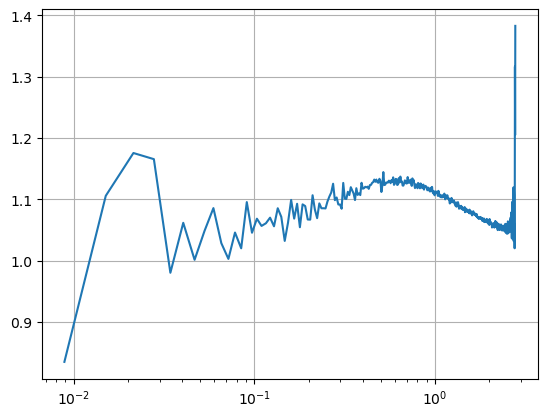

In [11]:
# ratio
plt.figure()
plt.plot(k_quijote_js, ratio)
plt.xscale('log')
plt.grid()


Text(0, 0.5, 'P(k) [(Mpc/h)^3]')

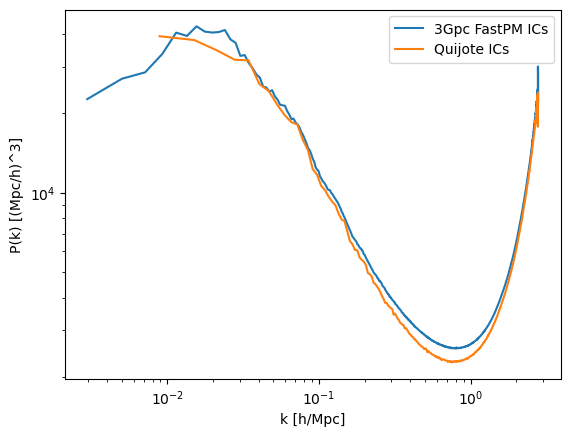

In [12]:
plt.figure()
plt.plot(k_mock_js, Pk0_mock_js, label='3Gpc FastPM ICs')
plt.plot(k_quijote_js, Pk0_quijote_js, label='Quijote ICs')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')




In [1]:
import asdf
# def loadAllHalos(halodir,zID,mMin=None):
data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000'
# zval = 2.149
zval = 0.019
# zval = 1.009
with asdf.open(f'{data_dir}/lightcone_halos/z{zval}/lightcone_halo_info_000.asdf') as af:
    print(af.tree)


    

{'asdf_library': {'author': 'The ASDF Developers', 'homepage': 'http://github.com/asdf-format/asdf', 'name': 'asdf', 'version': '4.0.0'}, 'history': {'extensions': [{'extension_class': 'abacusnbody.data.asdf.AbacusExtension', 'extension_uri': 'asdf://abacusnbody.org/extensions/abacus-0.0.1', 'software': {'name': 'abacusutils', 'version': '2.0.2.dev53+g6cdb02d.d20241213'}, 'supported_compression': ['blsc']}, {'extension_class': 'asdf.extension._manifest.ManifestExtension', 'extension_uri': 'asdf://asdf-format.org/core/extensions/core-1.6.0', 'manifest_software': {'name': 'asdf_standard', 'version': '1.1.1'}, 'software': {'name': 'asdf', 'version': '4.0.0'}}]}, 'halo_lightcone': {'HaloIndex': <array (unloaded) shape: [73578] dtype: int64>, 'InterpolatedComovingDist': <array (unloaded) shape: [73578] dtype: float32>, 'InterpolatedN': <array (unloaded) shape: [73578] dtype: float32>, 'InterpolatedPosition': <array (unloaded) shape: [73578, 3] dtype: float32>, 'InterpolatedVelocity': <array

In [2]:
import asdf

# zval = 1.009
with asdf.open(f'/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/halos/z0.000/halo_info/halo_info_000.asdf') as af:
    print(af.tree)


    

{'asdf_library': {'author': 'The ASDF Developers', 'homepage': 'http://github.com/asdf-format/asdf', 'name': 'asdf', 'version': '4.0.0'}, 'history': {'extensions': [{'extension_class': 'abacusnbody.data.asdf.AbacusExtension', 'extension_uri': 'asdf://abacusnbody.org/extensions/abacus-0.0.1', 'software': {'name': 'abacusutils', 'version': '2.0.2.dev53+g6cdb02d.d20241213'}, 'supported_compression': ['blsc']}, {'extension_class': 'asdf.extension._manifest.ManifestExtension', 'extension_uri': 'asdf://asdf-format.org/core/extensions/core-1.6.0', 'manifest_software': {'name': 'asdf_standard', 'version': '1.1.1'}, 'software': {'name': 'asdf', 'version': '4.0.0'}}]}, 'data': {'L0_N': <array (unloaded) shape: [29350718] dtype: uint32>, 'L2_N': <array (unloaded) shape: [29350718, 5] dtype: uint32>, 'N': <array (unloaded) shape: [29350718] dtype: uint32>, 'SO_L2max_central_density': <array (unloaded) shape: [29350718] dtype: float32>, 'SO_L2max_central_particle': <array (unloaded) shape: [2935071